Контекст
Вы работаете в отделе безопасности крупного банка. Перед вами стоит критически важная задача: разработать систему обнаружения мошеннических операций по кредитным картам в реальном времени. Для этого вам предоставили анонимизированный датасет транзакций.

Датасет: [Credit Card Fraud Detection]( https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

Постановка задачи
Проведите сравнительный анализ алгоритмов машинного обучения для задачи бинарной классификации транзакций на:

Легальные (Class = 0)

Мошеннические (Class = 1)

Задача 1. Предобработка данных (1 балл)

- Изучите распределение целевой переменной (анализ дисбаланса классов). Постройте графики

- Проведите масштабирование признаков (V1-V28 уже нормализованы, но Time и Amount требуют обработки)

- Разделите данные на обучающую и тестовую выборки (учтите стратификацию из-за дисбаланса)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
sns.set(style="whitegrid", font_scale=1.1)

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Абсолютное распределение классов:
Class
0    284315
1       492
Name: count, dtype: int64

Относительное распределение классов:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


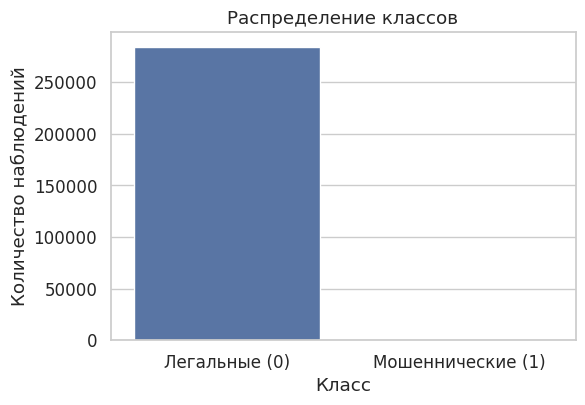

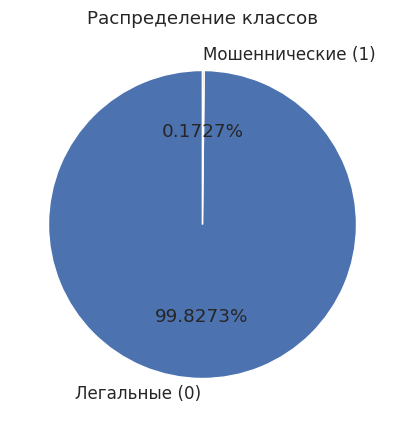

In [ ]:
class_counts = df["Class"].value_counts()
class_ratios = df["Class"].value_counts(normalize=True)

print("Абсолютное распределение классов:")
print(class_counts)
print("\nОтносительное распределение классов:")
print(class_ratios)

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks([0, 1], ["Легальные (0)", "Мошеннические (1)"])
plt.title("Распределение классов")
plt.ylabel("Количество наблюдений")
plt.xlabel("Класс")
plt.show()

plt.figure(figsize=(5,5))
plt.pie(class_counts.values,
        labels=["Легальные (0)", "Мошеннические (1)"],
        autopct='%1.4f%%',
        startangle=90)
plt.title("Распределение классов")
plt.show()


In [ ]:
scaler = StandardScaler()
df[["Time", "Amount"]] = scaler.fit_transform(df[["Time", "Amount"]])
df[["Time", "Amount"]].describe()

,Time,Amount
count,2.848070e+05,2.848070e+05
mean,-3.065637e-16,2.913952e-17
std,1.000002e+00,1.000002e+00
min,-1.996583e+00,-3.532294e-01
25%,-8.552120e-01,-3.308401e-01
50%,-2.131453e-01,-2.652715e-01
75%,9.372174e-01,-4.471707e-02
max,1.642058e+00,1.023622e+02


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размеры выборок:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train положительных классов:", y_train.sum())
print("y_test  положительных классов:", y_test.sum())

Размеры выборок:
X_train: (227845, 30)
X_test:  (56962, 30)
y_train положительных классов: 394
y_test  положительных классов: 98


Задача 2. Построение   моделей ( 2 балла)

Реализуйте следующие алгоритмы:

Базовые модели:

- Линейная регрессия (с пороговой функцией)

- kNN (k-ближайших соседей)

- Решающее дерево

Ансамблевые методы:

- Бэггинг (BaggingClassifier)

- Случайный лес (Random Forest)

- Стекинг (StackingClassifier) для моделей

  *   LogisticRegression,
  *  KNeighborsClassifier,
  *  DecisionTreeClassifier


Может долго работать, но примерно до 15-20 минут !

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, StackingClassifier

In [ ]:
y_pred = {}
y_pred_proba = {}

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin_reg_proba = lin_reg.predict(X_test)
y_pred_lin_reg = (y_pred_lin_reg_proba >= 0.5).astype(int) #порог = 0.5

y_pred["LinearRegression_thr0.5"] = y_pred_lin_reg
y_pred_proba["LinearRegression_thr0.5"] = y_pred_lin_reg_proba



knn = KNeighborsClassifier(
    n_neighbors=5
)
knn.fit(X_train, y_train)

y_pred["kNN"] = knn.predict(X_test)
y_pred_proba["kNN"] = knn.predict_proba(X_test)[:, 1]



dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train)

y_pred["DecisionTree"] = dt.predict(X_test)
y_pred_proba["DecisionTree"] = dt.predict_proba(X_test)[:, 1]


In [ ]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
    n_estimators=50,
    random_state=42
)
bagging.fit(X_train, y_train)

y_pred["Bagging_DT"] = bagging.predict(X_test)
y_pred_proba["Bagging_DT"] = bagging.predict_proba(X_test)[:, 1]



rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

y_pred["RandomForest"] = rf.predict(X_test)
y_pred_proba["RandomForest"] = rf.predict_proba(X_test)[:, 1]



base_estimators = [
    ("lr", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    )),
    ("knn", KNeighborsClassifier(
        n_neighbors=5
    )),
    ("dt", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
]

stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ),
    cv=3
)

stacking.fit(X_train, y_train)

y_pred["Stacking"] = stacking.predict(X_test)
y_pred_proba["Stacking"] = stacking.predict_proba(X_test)[:, 1]

Задача 3. Оценка моделей ( 2 балла )

Для каждой модели рассчитайте:

- Precision и Recall

- F1-score (основная метрика из-за дисбаланса)

- ROC-AUC

- Матрицу ошибок (Confusion Matrix)

Подсказка: Мы оцениваем на тестовой выборке

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

metrics = []

for model_name, y_hat in y_pred.items():
    prec = precision_score(y_test, y_hat, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_hat, pos_label=1, zero_division=0)
    f1  = f1_score(y_test, y_hat, pos_label=1, zero_division=0)

    if model_name in y_pred_proba:
        proba = y_pred_proba[model_name]
        proba = np.clip(proba, 0, 1)
        roc_auc = roc_auc_score(y_test, proba)
    else:
        roc_auc = np.nan

    metrics.append({
        "model": model_name,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc
    })

metrics_df = pd.DataFrame(metrics).set_index("model")
metrics_df.sort_values("f1", ascending=False)


,precision,recall,f1,roc_auc
model,,,,
kNN,0.918605,0.806122,0.858696,0.943756
RandomForest,0.961039,0.755102,0.845714,0.957189
Bagging_DT,0.973333,0.744898,0.843931,0.943112
DecisionTree,0.676190,0.724490,0.699507,0.861946
LinearRegression_thr0.5,0.775862,0.459184,0.576923,0.980200
Stacking,0.061898,0.918367,0.115979,0.972366


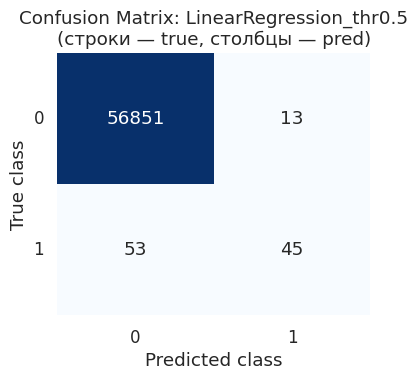

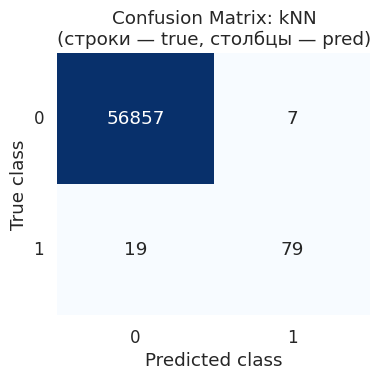

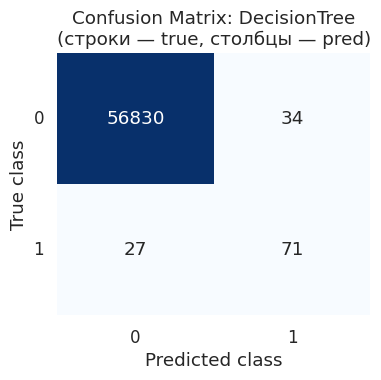

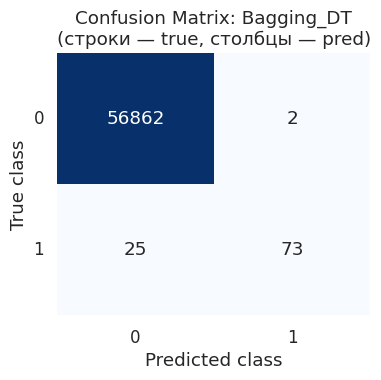

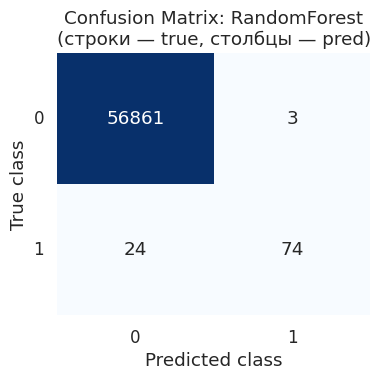

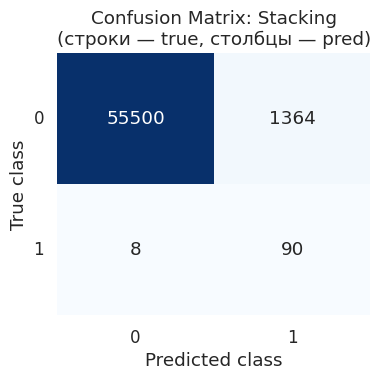

In [ ]:
for model_name, y_hat in y_pred.items():
    cm = confusion_matrix(y_test, y_hat)

    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False, ax=ax)

    ax.set_title(f"Confusion Matrix: {model_name}\n(строки — true, столбцы — pred)")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")

    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"], rotation=0)

    plt.tight_layout()
    plt.show()

Выводы: в задании 4.

Задача 4. Сравнительный анализ ( 1 балл)

Создайте сводную таблицу со всеми метриками и проведите анализ:

- Какая модель показывает наилучшее качество?

- Какие модели лучше обнаруживают мошеннические транзакции (высокий recall)?

- Какие модели минимизируют ложные срабатывания (высокий precision)?

Ответы: сводная таблица построена в задаче 4.

1. F1-score - основная метрика из-за дисбаланса(как указано в задании 3) По основной метрике F1 оптимальный компромисс даёт kNN, чуть хуже — RandomForest и Bagging.

2. Stacking побеждает по recall, правда плох по precision(модель объявляет фродом тысячи легальных транзакций)

3. Bagging_DT и RandomForest дают минимум ложных тревог(Bagging_DT чуть лучше), при этом всё ещё неплохо ловят фрод.

Задача 5. Углубленный анализ ошибок ( 2 балла)
- Проанализируйте ложно-положительные и ложно-отрицательные случаи лучшей модели

- Определите паттерны в транзакциях, которые модель классифицирует неправильно

- Визуализируйте распределение ошибок по признакам Amount и Time

In [ ]:
best_model = "kNN"

y_best = y_pred[best_model]

results = X_test.copy()
results["y_true"] = y_test
results["y_pred"] = y_best

conditions = [
    (results["y_true"] == 1) & (results["y_pred"] == 1),  # TP
    (results["y_true"] == 0) & (results["y_pred"] == 0),  # TN
    (results["y_true"] == 0) & (results["y_pred"] == 1),  # FP
    (results["y_true"] == 1) & (results["y_pred"] == 0),  # FN
]
choices = ["TP", "TN", "FP", "FN"]

results["error_type"] = np.select(conditions, choices, default="OTHER")
results["error_type"].value_counts()

,count
error_type,
TN,56857
TP,79
FN,19
FP,7


In [ ]:
fp = results[results["error_type"] == "FP"]
fn = results[results["error_type"] == "FN"]

print("FP shape:", fp.shape)
print("FN shape:", fn.shape)

print("FP - описательная статистика:")
display(fp[["Time", "Amount"]].describe())

print("FN - описательная статистика:")
display(fn[["Time", "Amount"]].describe())

FP shape: (7, 33)
FN shape: (19, 33)
FP - описательная статистика:


,Time,Amount
count,7.000000,7.000000
mean,-0.065265,-0.325220
std,0.985879,0.067904
min,-1.444507,-0.353229
25%,-0.665427,-0.351710
50%,0.090868,-0.350151
75%,0.625981,-0.349231
max,0.975680,-0.171276


FN - описательная статистика:


,Time,Amount
count,19.000000,19.000000
mean,-0.301709,0.064825
std,0.952289,0.825767
min,-1.986644,-0.349231
25%,-0.971631,-0.349231
50%,-0.370869,-0.338077
75%,0.327201,-0.087337
max,1.256719,2.185955


In [ ]:
tp = results[results["error_type"] == "TP"]
tn = results[results["error_type"] == "TN"]

print("TP - описательная статистика:")
display(tp[["Time", "Amount"]].describe())

print("TN - описательная статистика:")
display(tn[["Time", "Amount"]].describe())

TP - описательная статистика:


,Time,Amount
count,79.000000,79.000000
mean,-0.513915,0.084952
std,0.980460,0.961384
min,-1.988034,-0.353229
25%,-1.189064,-0.349231
50%,-0.757914,-0.307691
75%,-0.014843,0.094616
max,1.569513,6.882027


TN - описательная статистика:


,Time,Amount
count,56857.000000,56857.000000
mean,-0.005188,0.002677
std,0.999840,0.990465
min,-1.996541,-0.353229
25%,-0.856570,-0.331160
50%,-0.217378,-0.265271
75%,0.933753,-0.047456
max,1.641931,51.265782


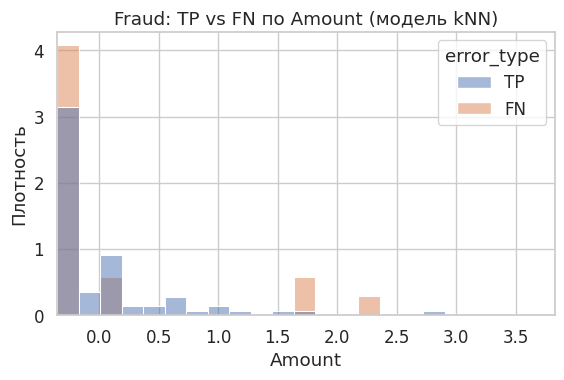

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(
    data=results[results["error_type"].isin(["TP", "FN"])],
    x="Amount",
    hue="error_type",
    bins=40,
    stat="density",
    common_norm=False
)
plt.title("Fraud: TP vs FN по Amount (модель kNN)")
plt.xlabel("Amount")
plt.ylabel("Плотность")
plt.xlim(results["Amount"].quantile(0.00), results["Amount"].quantile(0.99))  # обрезаем хвост
plt.tight_layout()
plt.show()


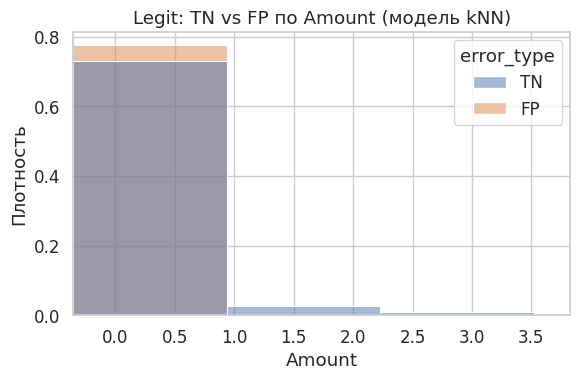

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(
    data=results[results["error_type"].isin(["TN", "FP"])],
    x="Amount",
    hue="error_type",
    bins=40,
    stat="density",
    common_norm=False
)
plt.title("Legit: TN vs FP по Amount (модель kNN)")
plt.xlabel("Amount")
plt.ylabel("Плотность")
plt.xlim(results["Amount"].quantile(0.00), results["Amount"].quantile(0.99))
plt.tight_layout()
plt.show()


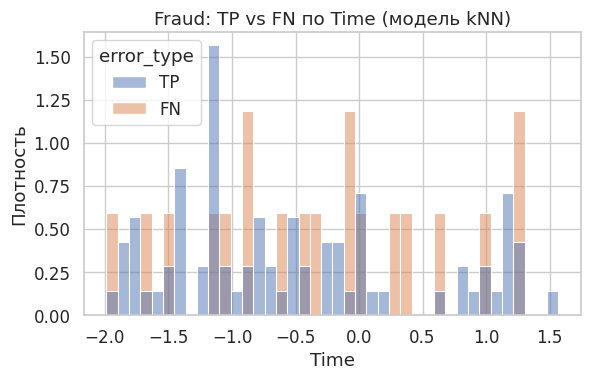

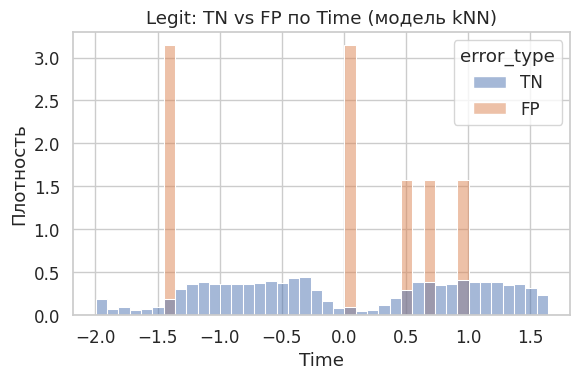

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(
    data=results[results["error_type"].isin(["TP", "FN"])],
    x="Time",
    hue="error_type",
    bins=40,
    stat="density",
    common_norm=False
)
plt.title("Fraud: TP vs FN по Time (модель kNN)")
plt.xlabel("Time")
plt.ylabel("Плотность")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(
    data=results[results["error_type"].isin(["TN", "FP"])],
    x="Time",
    hue="error_type",
    bins=40,
    stat="density",
    common_norm=False
)
plt.title("Legit: TN vs FP по Time (модель kNN)")
plt.xlabel("Time")
plt.ylabel("Плотность")
plt.tight_layout()
plt.show()


Выводы:

1. TP: 79; TN: 56 857; FN: 19; FP: 7 - то есть kNN почти не даёт ложных срабатываний (FP очень мало), но всё-таки пропускает часть мошеннических операций (19 из 98 фродов в тесте).

2. FN

Сумма операции(Amount):

Для FN медиана ≈ −0.34, 75-й перцентиль ≈ −0.09, максимум ≈ 2.19;

Для TP медиана ≈ −0.31, 75-й перцентиль ≈ 0.09, максимум ≈ 6.88;

Для TN медиана ≈ −0.27, 75-й перцентиль ≈ −0.05.

С учётом нормировки признаков это значит: большинство FN — это мелкие по сумме операции, лежащие в том же нижнем диапазоне, что и легальные транзакции.

TP имеют чуть более размазанный и сдвинутый вверх по Amount профиль: среди правильно пойманных фродов чаще встречаются операции со средними и крупными суммами.

По гистограмме "Fraud: TP vs FN по Amount" видно, что FN в основном сливаются с областью низких сумм, где много обычных операций.

Паттерн: kNN хуже всего ловит мелкий фрод, который по сумме ничем не выделяется на фоне обычных платежей.

Среднее Time: TP ≈ −0.51, FN ≈ −0.30, TN ≈ −0.01.

То есть FN по времени ближе к легальным транзакциям, чем TP.

На графике "Fraud: TP vs FN по Time" видно, что: TP чуть больше сосредоточены в нестандартных временных интервалах, FN сильнее перекрываются с плотностью TN.

Паттерн: мошеннические операции, которые совершаются в типичное время (похожее на легальные), модель чаще относит к классу 0 и пропускает.

Вывод по FN:
kNN пропускает, в первую очередь, небольшие по сумме мошенничества, происходящие в привычное для клиентов время. По двум простым признакам они выглядят “как обычная жизнь”, поэтому ближайшие соседи вокруг них — в основном легальные транзакции.

3. FP

Сумма операции(Amount): для FP медиана ≈ −0.35, верхний квартиль ≈ −0.35, максимум ≈ −0.17. То есть все FP лежат в нижнем диапазоне сумм – это небольшие платежи.

Распределение FP по Amount практически полностью перекрывается с TN и совсем не похоже на аномальные суммы. На графике "Legit: TN vs FP по Amount" видно, что FP сидят прямо в толще обычных операций.

Время (Time): для TN Time распределён довольно равномерно,
FP, судя по гистограмме "Legit: TN vs FP по Time", сгруппированы в нескольких узких временных интервалах, где плотность TN ниже.

Это можно интерпретировать так:

В этих интервалах времени у фрода, вероятно, повышенная концентрация ближайших соседей, поэтому kNN подтаскивает туда и часть легальных операций.

То есть модель немного переусердствует в отдельных подозрительных временных окнах, помечая редкие там легальные операции как фрод.

Вывод по FP:
ложно-положительные транзакции — это редкие по времени маленькие платежи, которые попадают в плохое соседство (рядом много фрода по скрытым признакам V1–V28). По Amount они не подозрительны, но в пространстве признаков оказываются близко к мошенничествам.

Задача 6. Подбор гиперпараметров (2 балла)

- Подберите оптимальные гиперпараметры с помощью [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) для лучшей модели.
-  Построй модель с лучшими параметрами и оцени
- Напиши выводы о лучшей модели.

In [24]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [26]:
knn_base = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"]
}
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший средний F1 (CV):", grid.best_score_)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Лучшие параметры: {'n_neighbors': 7, 'weights': 'distance'}
Лучший средний F1 (CV): 0.8298663727786197


In [27]:
best_knn = grid.best_estimator_

y_knn_tuned = best_knn.predict(X_test)
y_knn_tuned_proba = best_knn.predict_proba(X_test)[:, 1]

prec_tuned = precision_score(y_test, y_knn_tuned, pos_label=1, zero_division=0)
rec_tuned  = recall_score(y_test, y_knn_tuned, pos_label=1, zero_division=0)
f1_tuned   = f1_score(y_test, y_knn_tuned, pos_label=1, zero_division=0)
roc_tuned  = roc_auc_score(y_test, y_knn_tuned_proba)

print("kNN с лучшими параметрами:")
print("Precision:", prec_tuned)
print("Recall   :", rec_tuned)
print("F1       :", f1_tuned)
print("ROC-AUC  :", roc_tuned)


f1_old = f1_score(y_test, y_pred["kNN"], pos_label=1, zero_division=0)
print("\nСравнение F1:")
print("Исходный kNN:", f1_old)
print("Тюненный kNN:", f1_tuned)


kNN с лучшими параметрами:
Precision: 0.9156626506024096
Recall   : 0.7755102040816326
F1       : 0.8397790055248618
ROC-AUC  : 0.943739915071262

Сравнение F1:
Исходный kNN: 0.8586956521739131
Тюненный kNN: 0.8397790055248618


Выводы:

Для выбранной лучшей базовой модели kNN был проведён подбор гиперпараметров с помощью GridSearchCV (2-fold Stratified CV, метрика F1). Лучшие параметры по результатам кросс-валидации: n_neighbors = 7, weights = 'distance', средний F1 по CV ≈ 0.83.
При оценке на тестовой выборке исходная модель kNN (k=5, uniform) показала F1 ≈ 0.859, а улучшенная модель — F1 ≈ 0.840. Таким образом, настройка гиперпараметров не привела к улучшению качества на независимом тесте. Вероятная причина — шумность F1-метрики при малом числе положительных примеров и частичный оверфит на кросс-валидационных сплитах. В качестве финальной модели была оставлена исходная конфигурация kNN.

Следует отметить, что в целях снижения времени вычислений решётка гиперпараметров для kNN была выбрана относительно узкой (k ∈ {3, 5, 7}, два варианта weights, p = 2). В более широкой сетке, потенциально включающей больше значений k и другие метрики расстояния, могла бы быть найдена конфигурация с лучшим качеством, однако это потребовало бы существенно большего времени расчётов и могло усилить эффект переобучения на кросс-валидационных сплитах.